# Uczenie Nienadzorowane

### Model uzupełniający uszkodzenia dzieł sztuki

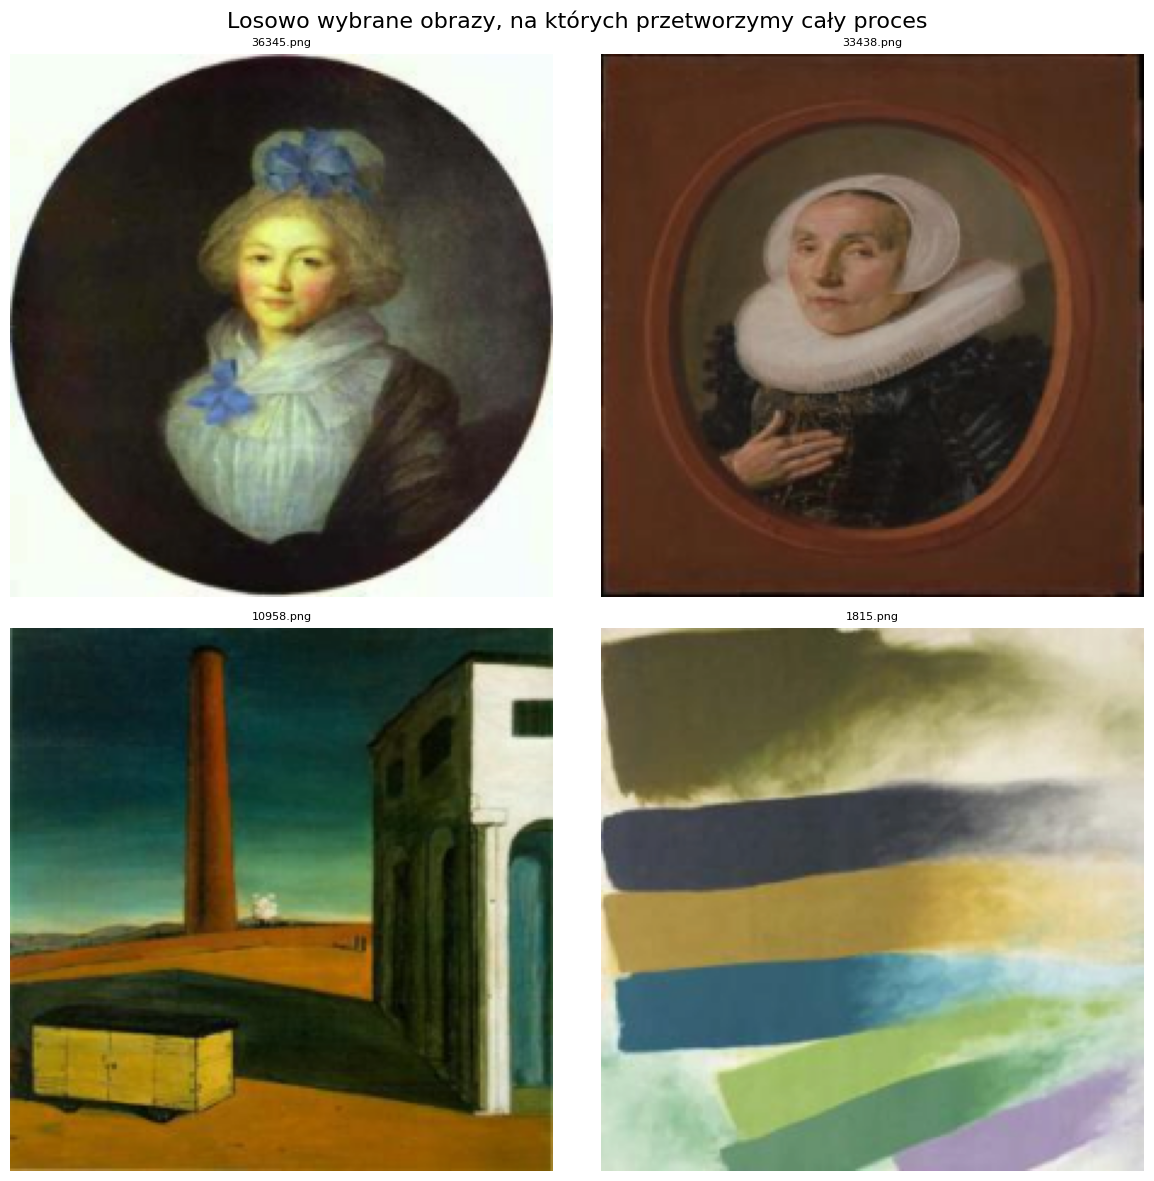

In [30]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_DIR = Path("test_images")
NUM_IMAGES = 4
IMAGE_SIZE = 256

if not IMAGE_DIR.is_dir():
    print(f"Błąd: Folder '{IMAGE_DIR}' nie został znaleziony.")
else:
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp']
    image_paths = [p for p in IMAGE_DIR.glob('*') if p.suffix.lower() in image_extensions]

    if not image_paths:
        print(f"W folderze '{IMAGE_DIR}' nie znaleziono żadnych obrazów.")
    else:
        num_to_select = min(len(image_paths), NUM_IMAGES)
        selected_paths = random.sample(image_paths, num_to_select)

        cols = 2
        rows = (num_to_select + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
        
        axes = axes.flatten()

        plt.suptitle(f"Losowo wybrane obrazy, na których przetworzymy cały proces", fontsize=16)
        
        for i, img_path in enumerate(selected_paths):
            try:
                with Image.open(img_path) as img:
                    ax = axes[i]
                    ax.imshow(img)
                    ax.set_title(img_path.name, fontsize=8)
                    ax.axis('off')
            except Exception as e:
                print(f"Nie udało się wczytać obrazu {img_path}: {e}")
        
        for j in range(num_to_select, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()

### Generowanie uszkodzeń 

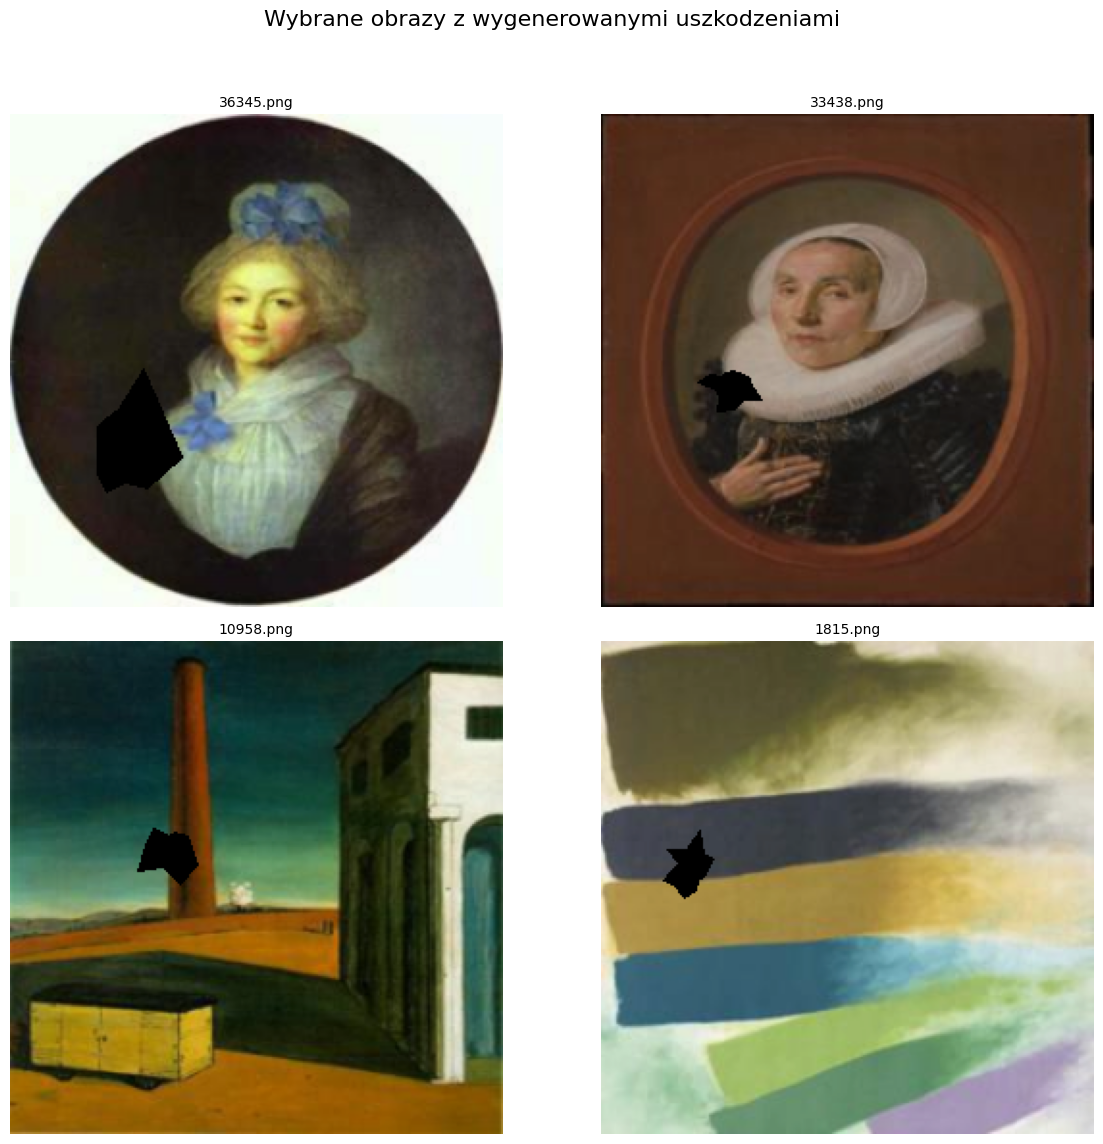

In [31]:
import numpy as np

from hole_generator.holes_generator import ImageHoleGenerator

DAMAGED_IMAGE_DIR = Path("damaged_images")

if 'selected_paths' not in locals() or not selected_paths:
    print("Błąd: Uruchom najpierw poprzednią komórkę, aby wylosować obrazy.")
    print("Zmienna 'selected_paths' nie została znaleziona lub jest pusta.")
else:
    DAMAGED_IMAGE_DIR.mkdir(exist_ok=True)

    hole_gen = ImageHoleGenerator(recreate_output_dir=False, holes=1)

    damaged_images_paths = []

    num_images = len(selected_paths)
    cols = 2
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
    fig.suptitle("Wybrane obrazy z wygenerowanymi uszkodzeniami", fontsize=16)
    axes = axes.flatten()

    for i, img_path in enumerate(selected_paths):
        damaged_path = DAMAGED_IMAGE_DIR / img_path.name
        img_to_display = None

        #
        if damaged_path.exists():
            img_to_display = Image.open(damaged_path).convert("RGB")
            damaged_images_paths.append(damaged_path)
        
        else:
        #
            try:
                with Image.open(img_path).convert("RGB") as original_img:
                    img_np = np.array(original_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
                    
                    hole_gen.image = img_np
                    
                    damaged_image_np, _ = hole_gen.generate_holes(max_hole_area_ratio=0.1)
                    
                    img_to_display = Image.fromarray(damaged_image_np)

                    img_to_display.save(damaged_path)
                    damaged_images_paths.append(damaged_path)

            except Exception as e:
                print(f"Nie udało się przetworzyć obrazu {img_path}: {e}")
                img_to_display = Image.new('RGB', (IMAGE_SIZE, IMAGE_SIZE), color='red')

        if img_to_display:
            ax = axes[i]
            ax.imshow(img_to_display)
            ax.set_title(img_path.name, fontsize=10)
            ax.axis('off')

    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Przetworzenie obrazów: Ekstrakcja cech (enkoder)

In [32]:
import torch
from torchvision import transforms as T

from autoencoders.resnet_autoencoder import ResNetEncoder

ENCODER_WEIGHTS_PATH = "runs/resnet_ae_os16/encoder_best.pt"
BACKBONE = "resnet18"
OUTPUT_STRIDE = 16

if 'damaged_images_paths' not in locals() or not damaged_images_paths:
    print("Błąd: Uruchom najpierw poprzednią komórkę, aby wygenerować uszkodzone obrazy.")
    print("Zmienna 'damaged_images_paths' nie została znaleziona lub jest pusta.")
else:
    print("Ładowanie modelu enkodera...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Używane urządzenie: {device}")

    encoder = ResNetEncoder(
        name=BACKBONE,
        pretrained=False,
        output_stride=OUTPUT_STRIDE,
        return_stages=("C5", "C4", "C3", "C2", "C1"),
    ).to(device)

    weights_path = Path(ENCODER_WEIGHTS_PATH)
    if not weights_path.exists():
        raise FileNotFoundError(f"Błąd krytyczny: Nie znaleziono wag enkodera pod ścieżką '{weights_path}'")
    
    encoder.load_state_dict(torch.load(weights_path, map_location=device))
    encoder.eval()
    print("Model enkodera załadowany i ustawiony w tryb ewaluacji.")

    transform = T.Compose([
        T.Resize(IMAGE_SIZE),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])

    extracted_features = []
    print(f"\nPrzetwarzanie {len(damaged_images_paths)} obrazów w celu ekstrakcji cech...")

    with torch.no_grad():
        for i, image_path in enumerate(damaged_images_paths):
            try:
                image = Image.open(image_path).convert("RGB")
                
                img_tensor = transform(image).unsqueeze(0).to(device)
                
                features = encoder(img_tensor)
                
                bottleneck_feature = features[0]
                extracted_features.append(bottleneck_feature)
                
                print(f"  [{i+1}/{len(damaged_images_paths)}] Przetworzono '{image_path.name}'. Kształt cechy: {bottleneck_feature.shape}")

            except Exception as e:
                print(f"Błąd podczas przetwarzania obrazu {image_path.name}: {e}")

    print("\nEkstrakcja cech zakończona.")

Ładowanie modelu enkodera...
Używane urządzenie: cpu
Model enkodera załadowany i ustawiony w tryb ewaluacji.

Przetwarzanie 4 obrazów w celu ekstrakcji cech...
  [1/4] Przetworzono '36345.png'. Kształt cechy: torch.Size([1, 512, 16, 16])
  [2/4] Przetworzono '33438.png'. Kształt cechy: torch.Size([1, 512, 16, 16])
  [3/4] Przetworzono '10958.png'. Kształt cechy: torch.Size([1, 512, 16, 16])
  [4/4] Przetworzono '1815.png'. Kształt cechy: torch.Size([1, 512, 16, 16])

Ekstrakcja cech zakończona.


### Przyporządkowanie obrazów do danej grupy (klasteryzacja)

In [33]:
from clustering.predict_cluster import predict_cluster

if 'extracted_features' not in locals() or not extracted_features:
    print("Błąd: Uruchom najpierw komórkę ekstrakcji cech.")
    print("Zmienna 'extracted_features' nie została znaleziona lub jest pusta.")
elif 'damaged_images_paths' not in locals() or len(damaged_images_paths) != len(extracted_features):
    print("Błąd: Brak spójności danych. Liczba ścieżek obrazów nie zgadza się z liczbą cech.")
    print("Uruchom ponownie komórki generujące uszkodzenia i cechy.")
else:
    print("Rozpoczynanie predykcji klastrów dla wyekstrahowanych cech...")
    
    predicted_clusters = []
    
    for i, feature_tensor in enumerate(extracted_features):
        cluster_id = predict_cluster(feature_tensor.cpu())
        predicted_clusters.append(cluster_id)
        
        image_name = damaged_images_paths[i].name
        print(f"  -> Obraz '{image_name}' przypisano do klastra: {cluster_id}")

    print("\nPredykcja klastrów zakończona.")
    print("Utworzono listę 'predicted_clusters' do dalszego użytku.")
    print(f"Przypisane klastry: {predicted_clusters}")



Rozpoczynanie predykcji klastrów dla wyekstrahowanych cech...
  -> Obraz '36345.png' przypisano do klastra: 6
  -> Obraz '33438.png' przypisano do klastra: 6
  -> Obraz '10958.png' przypisano do klastra: 6
  -> Obraz '1815.png' przypisano do klastra: 6

Predykcja klastrów zakończona.
Utworzono listę 'predicted_clusters' do dalszego użytku.
Przypisane klastry: [np.int32(6), np.int32(6), np.int32(6), np.int32(6)]


c:\Users\gora-\anaconda3\envs\un_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gora-\anaconda3\envs\un_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\gora-\anaconda3\envs\un_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.8.0. This might lead

### Reksonstrukcja obrazu z reprezentacji cech (dekoder) i inpainting

In [ ]:
from pathlib import Path
from collections import defaultdict
import torch
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm

from autoencoders.resnet_autoencoder import ResNetEncoder
from clustering.predict_cluster import predict_cluster

INPUT_DIR = Path("a")
EXCLUDED_CLUSTER = 6
IMAGE_SIZE = 256

ENCODER_WEIGHTS_PATH = "runs/resnet_ae_os16/encoder_best.pt"
BACKBONE = "resnet18"
OUTPUT_STRIDE = 16

if not INPUT_DIR.is_dir():
    print(f"Błąd: Folder '{INPUT_DIR}' nie został znaleziony.")
else:
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp']
    image_paths = [p for p in INPUT_DIR.glob('*') if p.suffix.lower() in image_extensions]

    if not image_paths:
        print(f"W folderze '{INPUT_DIR}' nie znaleziono żadnych obrazów.")
    else:
        print("Ładowanie modelu enkodera...")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        encoder = ResNetEncoder(
            name=BACKBONE,
            pretrained=False,
            output_stride=OUTPUT_STRIDE,
            return_stages=("C5", "C4", "C3", "C2", "C1"),
        ).to(device)

        weights_path = Path(ENCODER_WEIGHTS_PATH)
        if not weights_path.exists():
            raise FileNotFoundError(f"Błąd krytyczny: Nie znaleziono wag enkodera pod ścieżką '{weights_path}'")

        encoder.load_state_dict(torch.load(weights_path, map_location=device))
        encoder.eval()
        print(f"Model załadowany na urządzenie: {device}")

        transform = T.Compose([
            T.Resize(IMAGE_SIZE),
            T.CenterCrop(IMAGE_SIZE),
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

        clusters_map = defaultdict(list)
        print(f"\nZnaleziono {len(image_paths)} obrazów. Rozpoczynanie przetwarzania...")

        with torch.no_grad():
            for image_path in tqdm(image_paths, desc="Przetwarzanie obrazów"):
                try:
                    image = Image.open(image_path).convert("RGB")
                    img_tensor = transform(image).unsqueeze(0).to(device)
                    
                    features_list = encoder(img_tensor)
                    bottleneck_feature = features_list[0]
                    
                    cluster_id = predict_cluster(bottleneck_feature.cpu())
                    cluster_id = int(cluster_id)
                    
                    clusters_map[cluster_id].append(image_path.name)
                    
                except Exception as e:
                    tqdm.write(f"Wystąpił błąd podczas przetwarzania '{image_path.name}': {e}")

        print("\n\n--- Podsumowanie Klastryzacji ---")
        if not clusters_map:
            print("Nie udało się pomyślnie przetworzyć żadnych obrazów.")
        else:
            sorted_clusters = sorted(clusters_map.items())
            
            found_any_to_display = False
            for cluster_id, filenames in sorted_clusters:
                if cluster_id != EXCLUDED_CLUSTER:
                    print(f"Klaster {cluster_id}: {filenames}")
                    found_any_to_display = True
            
            if not found_any_to_display:
                print(f"Nie znaleziono obrazów w klastrach innych niż wykluczony (ID: {EXCLUDED_CLUSTER}).")


Ładowanie modelu enkodera...
Model załadowany na urządzenie: cpu

Znaleziono 957 obrazów. Rozpoczynanie przetwarzania...


Przetwarzanie obrazów:   0%|          | 0/957 [00:00<?, ?it/s]c:\Users\gora-\anaconda3\envs\un_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Przetwarzanie obrazów:   0%|          | 1/957 [00:00<02:47,  5.72it/s]c:\Users\gora-\anaconda3\envs\un_env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Przetwarzanie obrazów:   0%|          | 2/957 [00:00<02:47,  5.71it/



--- Podsumowanie Klastryzacji ---
Nie znaleziono obrazów w klastrach innych niż wykluczony (ID: 6).
